In [2]:
from lightmatter.fdtd import run_simulation
from lightmatter.fdtd import MaterialParamsTD, PulseParams, FDTDParams
from lightmatter.io import load_simulation_run, make_fdtd_gif, plot_fdtd_frame, save_simulation_run
# from lightmatter.infer_drude_params import infer_drude_time_series_from_multifrequency_runs, extract_transfer_time_series_from_run
import numpy as np
import matplotlib.pyplot as plt
from lightmatter.units import C0, C0_SI, UNIT_F, UNIT_L, UNIT_T, UNIT_E

In [6]:
# Grid + time
L = 60 * 1e4 # A
dz= 10.0 # A
Nz = int(L/dz)
dt = 0.99 * dz / C0

# Source
src_pos = 5.0 * 1e4
src_i = int(np.round(src_pos/dz))

# ----------------metal film, up to right boundary---------------------#
metal_i0_pos = 50.0 * 1e4
metal_i1_pos = L
metal_i0 = int(np.round( metal_i0_pos/ dz))
metal_i1 = Nz
thickness = L - metal_i0_pos

#------------------ very thin metal film, but at the same position----------------#
# thickness = 5.0 # 10 A
# metal_i0_pos = 50.0 * 1e4
# metal_cells = int(np.round(thickness / dz))
# metal_i0 = int(np.round( metal_i0_pos/ dz))
# metal_i1 = metal_i0 + metal_cells

print(f"metal i0: {metal_i0}, i1: {metal_i1}, thickness:{thickness} A")

#probes, for thin film
# probe_r_pos = 10.0 * 1e4
# probe_t_pos = metal_i0_pos + 2.0e4
# probe_r_i = int(np.round(probe_r_pos/dz))
# probe_t_i = int(np.round(probe_t_pos/dz))

# probes for semi-infinite metal
probe_r_pos = 10.0 * 1e4
probe_t_pos = metal_i0_pos + 2.0e4
probe_r_i = int(np.round(probe_r_pos/dz))
probe_t_i = int(np.round(probe_t_pos/dz))
print(f"ref probe pos: {probe_r_i}, transmitted probe pos: {probe_t_i}")


#------------------Pulse parameters---------------#
E0_SI = 0.1 * 1e10   #  E0 in V / m (0.1 V / A)
E0 = E0_SI / UNIT_E  #  in code units
f0 = 370.0           #  THz
tau = 0.2 * 0.5      #  200 fs
t0 = 3*tau
pulsetype = "smoothed box"
pulse = PulseParams(E0=E0, f0=f0, t0=t0, tau=tau, phase=0.0, type=pulsetype)

T_estimate_reflection = (metal_i0_pos - src_pos + metal_i0_pos - probe_r_pos) / C0 + t0*2.0

T = np.round(T_estimate_reflection + 0.005, 3) #ps
Nt = int(T/dt)
num_snaps = 5000
print(f"Nt = {Nt}, number of snapshots = {Nt//num_snaps * 0}, set to zero for now")

#------------------Simulation box parameters (with film)---------------#
simulation_params_withfilm = FDTDParams(
    Nz=Nz,
    Nt=Nt,
    dz=dz,
    dt=dt,
    src_i=src_i,
    probe_t_i=probe_t_i,
    probe_r_i=probe_r_i,
    metal_i0=metal_i0,
    metal_i1=metal_i1,
    snap_every= 0,  # 0 disables snapshots
)

#------------------Simulation box parameters (without film)---------------#
simulation_params_nofilm = FDTDParams(
    Nz=Nz,
    Nt=Nt,
    dz=dz,
    dt=dt,
    src_i=src_i,
    probe_t_i=probe_t_i,
    probe_r_i=probe_r_i,
    metal_i0=metal_i0,
    metal_i1=metal_i0, # make metal thickness=0.0
    snap_every= 0,   # 0 disables snapshots
)

#------------------Material parameters (time-dependent)---------------#
def omega_D_smoothstep(t, omega0, delta, t0, deltat):
    step = 0.5 * (1.0 + np.tanh((t - t0) / deltat))
    return omega0 + delta * step

t_ax = np.linspace(0.0,T,Nt)
omega_D0 = 2 * np.pi * 2113.6
omega_D_timedep = omega_D_smoothstep(t_ax, omega_D0, 3000, 0.45, 0.02)
omega_D_const = np.ones(Nt) * omega_D0

gamma_D0 = 2.0 * np.pi * 15.92
# gamma_D_timedep = omega_D_smoothstep(t_ax, gamma_D0, 20, 0.58, 0.01)
gamma_D_const = np.ones(Nt) * gamma_D0

material = MaterialParamsTD(
    omega_D=omega_D_const, 
    gamma_D=gamma_D_const,
    omega_L=np.ones(Nt) * 2.0*np.pi*650.07, 
    gamma_L=np.ones(Nt) * 2.0*np.pi*104.86,
    del_eps=np.ones(Nt) * 1.09 * 0.0,        #lorentz off
    eps_inf=np.ones(Nt) * 5.9673,
)


metal i0: 50000, i1: 60000, thickness:100000.0 A
ref probe pos: 10000, transmitted probe pos: 52000
Nt = 269207, number of snapshots = 0, set to zero for now


## Test plots

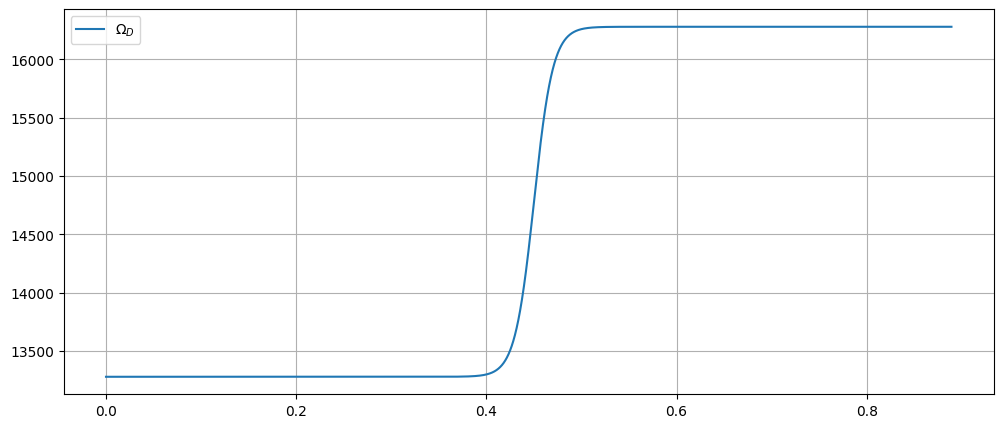

simulation time: 0.889 ps


In [7]:
fig = plt.figure(figsize=(12,5))
plt.plot(t_ax, omega_D_timedep, label=r"$\Omega_D$")
# plt.scatter(t_ax, gamma_D_timedep, label=r"$\Gamma_D$")
plt.legend()
plt.grid(True)
plt.show()
print(f"simulation time: {T} ps")

## Run FDTD simulation

In [8]:
for freq in [650.0,750.0,850.0]:
    pulse = PulseParams(E0=E0, f0=freq, t0=t0, tau=tau, phase=0.0, type=pulsetype)

    # filename vars
    dz_filename = 10
    root_dirname = "2026-06-01_reflection_compare_thick"
    
    #------------------constant parameters------------------#
    dirname = f"{root_dirname}/constant/f0_{freq}_step_dz_{dz_filename}"
    material = MaterialParamsTD(
        omega_D=omega_D_const, 
        gamma_D=gamma_D_const,
        omega_L=np.ones(Nt) * 2.0*np.pi*650.07, 
        gamma_L=np.ones(Nt) * 2.0*np.pi*104.86,
        del_eps=np.ones(Nt) * 1.09 * 0.0,        #lorentz off
        eps_inf=np.ones(Nt) * 5.9673,
    )

    E_t, E_r, snaps_t, snaps_E = run_simulation(simulation_params_withfilm, pulse, material, method="exact pml")

    save_simulation_run(
        folder=f"../output/{dirname}/with_film",
        params=simulation_params_withfilm, 
        pulse=pulse,
        material=material,
        E_t=E_t,
        E_r=E_r,
        snaps_t=snaps_t,
        snaps_E=snaps_E,
    )

    E_t, E_r, snaps_t, snaps_E = run_simulation(simulation_params_nofilm, pulse, material, method="exact pml")

    save_simulation_run(
        folder=f"../output/{dirname}/nofilm",
        params=simulation_params_nofilm,
        pulse=pulse,
        material=material,
        E_t=E_t,
        E_r=E_r,
        snaps_t=snaps_t,
        snaps_E=snaps_E,
    )

    #------------------time-varying parameters------------------#
    dirname = f"{root_dirname}/vary/f0_{freq}_step_dz_{dz_filename}"
    material = MaterialParamsTD(
        omega_D=omega_D_timedep, 
        gamma_D=gamma_D_const,
        omega_L=np.ones(Nt) * 2.0*np.pi*650.07, 
        gamma_L=np.ones(Nt) * 2.0*np.pi*104.86,
        del_eps=np.ones(Nt) * 1.09 * 0.0,        #lorentz off
        eps_inf=np.ones(Nt) * 5.9673,
    )

    E_t, E_r, snaps_t, snaps_E = run_simulation(simulation_params_withfilm, pulse, material, method="exact pml")

    save_simulation_run(
        folder=f"../output/{dirname}/with_film",
        params=simulation_params_withfilm, 
        pulse=pulse,
        material=material,
        E_t=E_t,
        E_r=E_r,
        snaps_t=snaps_t,
        snaps_E=snaps_E,
    )

    E_t, E_r, snaps_t, snaps_E = run_simulation(simulation_params_nofilm, pulse, material, method="exact pml")

    save_simulation_run(
        folder=f"../output/{dirname}/nofilm",
        params=simulation_params_nofilm,
        pulse=pulse,
        material=material,
        E_t=E_t,
        E_r=E_r,
        snaps_t=snaps_t,
        snaps_E=snaps_E,
    )

Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-01_reflection_compare_thick/constant/f0_650.0_step_dz_10/with_film
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-01_reflection_compare_thick/constant/f0_650.0_step_dz_10/nofilm
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-01_reflection_compare_thick/vary/f0_650.0_step_dz_10/with_film
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-01_reflection_compare_thick/vary/f0_650.0_step_dz_10/nofilm
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-01_reflection_compare_thick/constant/f0_750.0_step_dz_10/with_film
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-01_reflection_compare_thick/constant/f0_750.0_step_dz_10/nofilm
Maximum correction: 0.22795592420641053
Simulation saved to: ../output/2026-06-01_reflection_compare_thick/vary/f0_750.0_step_dz_10/with_film

## Retrieve data

In [73]:
# high resolution runs
# dirname_const = "2026-04-28_reflection_compare_constant_hires/constant/f0_750.0_step_dz_2.5"
# dirname_vary = "2026-04-28_reflection_compare_constant_hires/vary/f0_750.0_step_dz_2.5"

# low resolution
f0_retr = 750.0
dirname_const = f"2026-06-01_reflection_compare_thick/constant/f0_{f0_retr}_step_dz_10"
dirname_vary = f"2026-06-01_reflection_compare_thick/vary/f0_{f0_retr}_step_dz_10"

result_withfilm = load_simulation_run(f"../output/{dirname_const}/with_film",nosnaps=True)
result_nofilm = load_simulation_run(f"../output/{dirname_const}/nofilm",nosnaps=True)
result_withfilm_vary = load_simulation_run(f"../output/{dirname_vary}/with_film",nosnaps=True)
result_nofilm_vary = load_simulation_run(f"../output/{dirname_vary}/nofilm",nosnaps=True)

E_r_const = result_withfilm["E_r"] - result_nofilm["E_r"]
E_r_vary = result_withfilm_vary["E_r"] - result_nofilm_vary["E_r"]

E_t_const = result_withfilm["E_t"]
E_t_vary = result_withfilm_vary["E_t"]

Nt = result_withfilm["params"].Nt
dt = result_withfilm["params"].dt * UNIT_T
dz_retrieved = result_withfilm["params"].dz * UNIT_L
t_ax_retrieved = np.arange(Nt) * dt
f0 = result_withfilm["pulse"].f0 * UNIT_F
print(f"retrieved Pulse central frquency: {f0/UNIT_F} THz")
thickness_retrieved = (result_withfilm['params'].metal_i1 - result_withfilm['params'].metal_i0) * result_withfilm['params'].dz * UNIT_L

simulation_params_withfilm = result_withfilm['params']

retrieved Pulse central frquency: 750.0 THz


## Waveform plots

(750000.0, 950000.0)

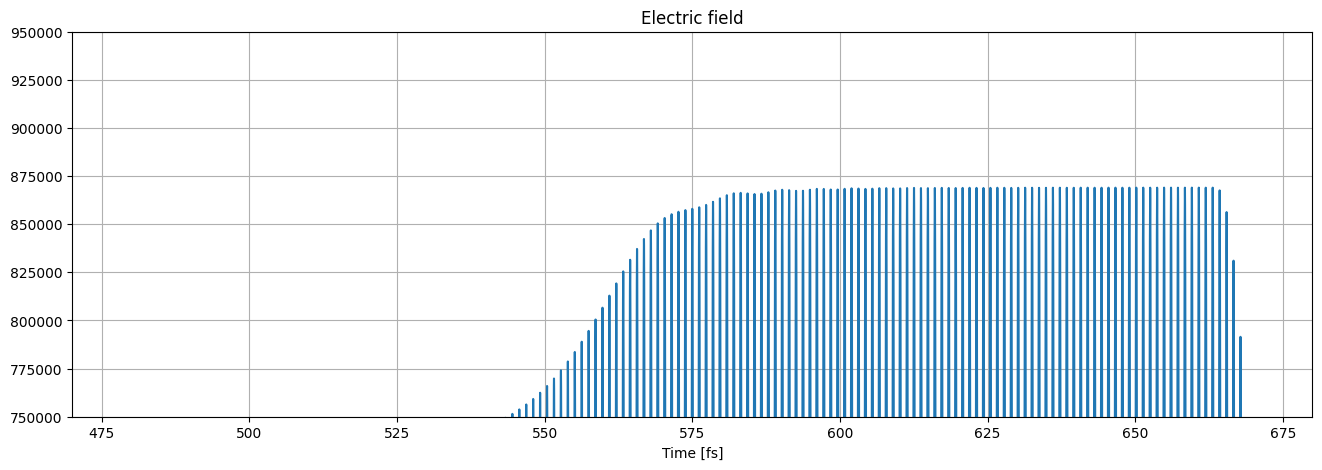

In [67]:
E_ref_vary = result_withfilm_vary["E_r"] - result_nofilm_vary["E_r"]
E_ref_const = result_withfilm["E_r"] - result_nofilm["E_r"]

# int_E_ref_vary = np.cumsum(E_ref_vary) * dt
# int_E_ref_const = np.cumsum(E_ref_const) * dt

fig = plt.figure(figsize=(16,5))
plt.plot(t_ax_retrieved*1e15, E_r_vary,label="varying")
plt.plot(t_ax_retrieved*1e15, E_r_const,label="static")
plt.title("Electric field")
plt.xlabel("Time [fs]")
plt.grid(True)
plt.xlim((4.7e2,6.8e2))
plt.ylim((750000, 950000))

### Integrated E field

In [10]:
from lightmatter.infer_drude_comp_const_interpolate import extract_peak_ratio_time_series_from_reflections
from lightmatter.infer_drude_reflection import epsilon_drude


t_mid, ratio_complex, aux = extract_peak_ratio_time_series_from_reflections(
    int_E_ref_const,
    int_E_ref_vary,
    t_ax_retrieved,
    f0,
    peak_prom_frac=1e-3,
    peak_tol_frac=0.45,
    clip=2,
)

Nt_reduced = Nt//100

t_ax_reduced = np.linspace(0.0,T,Nt_reduced)

omega_D_timedep_reduced = omega_D_smoothstep(t_ax_reduced, omega_D0, 3000, 0.45, 0.02)
omega_arr = np.array([2*np.pi*f0_retr,]) * UNIT_F               # Ensuring this is the same as the retrieved pulse
eps_drude = np.zeros(Nt_reduced,dtype=np.complex128)

for i in range(Nt_reduced):

    eps_drude[i] = epsilon_drude(
        omega=omega_arr,
        eps_inf=5.9673,
        omega_D=omega_D_timedep_reduced[i]*UNIT_F,
        gamma_D=gamma_D0*UNIT_F
    )[0]

eps_static = epsilon_drude(
    omega=omega_arr,
    eps_inf=5.9673,
    omega_D=omega_D0*UNIT_F,
    gamma_D=gamma_D0*UNIT_F,
) * np.ones_like(eps_drude,dtype=np.complex128)

chi_ratio = (eps_drude-1.0) / (eps_static-1.0)

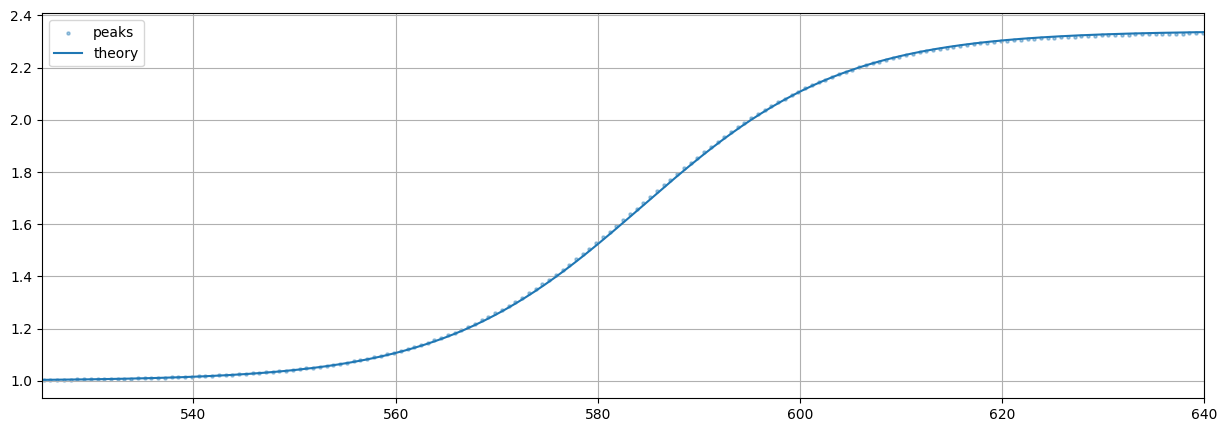

In [11]:
delta_t_correction = (result_withfilm_vary["params"].metal_i0 - result_withfilm_vary["params"].probe_r_i)*dz_retrieved / C0_SI

fig = plt.figure(figsize=(15,5))
plt.scatter(t_mid * 1e15, np.abs(ratio_complex),s=5, alpha=0.4,label="peaks")
plt.plot((t_ax_reduced*UNIT_T + delta_t_correction)*1e15, np.abs(chi_ratio),label="theory")
# plt.plot((t_ax_reduced*UNIT_T + delta_t_correction)*1e15, np.abs(r_ratio_old),label="not including derivative")
plt.legend()
plt.xlim((5.25e2,6.4e2))
# plt.ylim((0.999,1.03))
# plt.ylim((0.999, 2.5))
plt.grid(True)

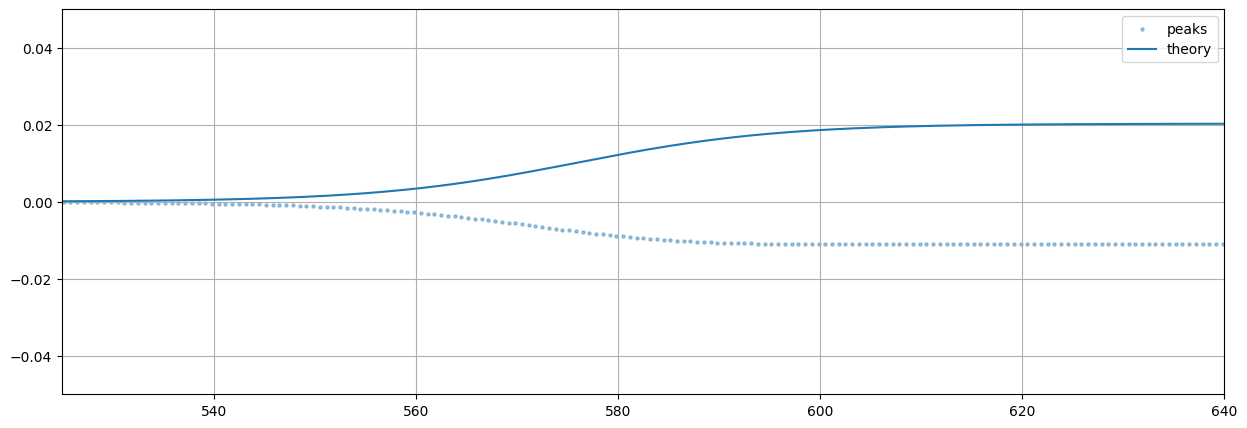

In [15]:
fig = plt.figure(figsize=(15,5))
plt.scatter(t_mid * 1e15, np.angle(ratio_complex),s=5, alpha=0.4,label="peaks")
plt.plot((t_ax_reduced*UNIT_T + delta_t_correction)*1e15, np.angle(chi_ratio),label="theory")
plt.legend()
plt.xlim((5.25e2,6.4e2))
plt.ylim((-0.05,0.05))
plt.grid(True)

(0.9, 1.05)

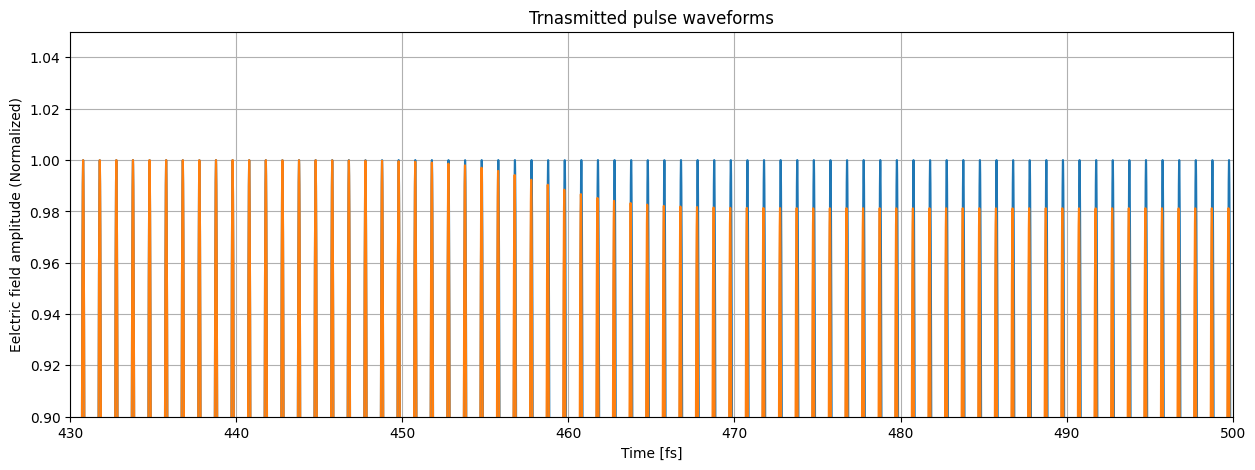

In [25]:
fig = plt.figure(figsize=(15,5))
plt.plot(t_ax_retrieved*1e15, E_t_const / (np.max(E_t_const)))
plt.plot(t_ax_retrieved*1e15, E_t_vary / (np.max(E_t_const)))
plt.title("Trnasmitted pulse waveforms")
plt.ylabel("Eelctric field amplitude (Normalized)")
plt.xlabel("Time [fs]")
plt.grid(True)
plt.xlim((4.3e2,5e2))
plt.ylim((0.9, 1.05))

## Shifted resonance for varying Drude parameters

In [30]:
# from lightmatter.utils import epsilon_analytical_drude_lorentz
# from lightmatter.infer_drude_reflection import r_finite_reflections

# wd_0_arr = [1500.0, 2113.6, 2600.0]

# fig,ax = plt.subplots(figsize=(12,5))
# for wd in wd_0_arr:
#     f_thz, eps = epsilon_analytical_drude_lorentz(Delta_eps=0.0, wD_over_2pi_THz=wd, plot=False, convert_to_photon=False)
#     n2_arr = np.sqrt(eps)
#     r_coeff = np.zeros_like(n2_arr) 
#     # Fresnel amplitude coefficients at normal incidence
#     # r12 = (n1 - n2) / (n1 + n2)
#     # reflection coefficient of a thin film
#     for i,n2 in enumerate(n2_arr):
#         r_coeff[i] = r_finite_reflections(
#             n=np.real(n2),
#             k=np.imag(n2),
#             d_m=thickness_retrieved,
#             w=wd*UNIT_F,
#             N_reflections=50
#         )
    
#     ax.plot(f_thz,np.abs(r_coeff), label=f"$\Omega_D = {np.round(2.0*np.pi*wd,1)}$ THz")

# plt.title("Reflection coefficient for varying plasma frequencies")
# plt.ylabel(r"$r$")
# plt.xlabel("$f$ [THz]")
# plt.legend()
# plt.xlim((300,1500))
# # plt.ylim((-1,1))


## check peaks analysis against theory, thin film

In [45]:
# perform a forward model check with the complex transfer function from the peak analysis

from lightmatter.infer_drude_reflection import epsilon_drude
from lightmatter.infer_drude_reflection import r_model_from_params

num_reflections = 100
Nt_reduced = Nt//100
r_ratio = np.zeros(Nt_reduced, dtype=np.complex128)
t_ax_reduced = np.linspace(0.0,T,Nt_reduced)
delta_t_grad = (t_ax_reduced[1] - t_ax_reduced[0]) * UNIT_T
print(f"T:{T}, 1/dt_reduced:{np.round(1/(t_ax_reduced[1] - t_ax_reduced[0])*1/UNIT_T,3)}")

omega_D_timedep_reduced = omega_D_smoothstep(t_ax_reduced, omega_D0, 3000, 0.45, 0.02)
omega_arr = np.array([2*np.pi*f0_retr,]) * UNIT_F               # Ensuring this is the same as the retrieved pulse
eps_drude = np.zeros(Nt_reduced,dtype=np.complex128)
r_dyn_old = np.zeros(Nt_reduced,dtype=np.complex128)

r_dyn_modified = np.zeros(Nt_reduced, dtype=np.complex128)

for i in range(Nt_reduced):

    eps_drude[i] = epsilon_drude(
        omega=omega_arr,
        eps_inf=5.9673,
        omega_D=omega_D_timedep_reduced[i]*UNIT_F,
        gamma_D=gamma_D0*UNIT_F
    )[0]

    # r_dyn_old[i] = r_model_from_params(
    #     omega=omega_arr,
    #     omega_D=omega_D_timedep_reduced[i]*UNIT_F,
    #     gamma_D=gamma_D0*UNIT_F,
    #     eps_inf=5.9673,
    #     d_m=thickness_retrieved,
    #     N_reflections=num_reflections,
    # )

# Check the expected reflection coefficient for a time-vary refractive index.

del_eps_del_t = np.gradient(eps_drude,delta_t_grad)
del2_eps_del_t2 = np.gradient(del_eps_del_t,delta_t_grad)

n_sqr = eps_drude - 1.0j/omega_arr[0] * del_eps_del_t
n_complex = np.sqrt(n_sqr)
n_sqr_uncorrected = eps_drude
n_complex_uncorrected = np.sqrt(eps_drude)

t_complex_vary = 1.0 + 1.0j * omega_arr[0] * thickness_retrieved / (2.0 * C0_SI) * (1.0 + n_sqr)
r_complex_vary = (0.5j*omega_arr[0]*thickness_retrieved / C0_SI)*(n_sqr - 1.0) * t_complex_vary # derived

# time-constant case
eps_drude_const = epsilon_drude(omega_arr, eps_inf=5.9673, omega_D=omega_D0*UNIT_F, gamma_D=gamma_D0*UNIT_F, )
t_complex_const = 1.0 + 1.0j * omega_arr[0] * thickness_retrieved / (2.0 * C0_SI) * (1.0 + eps_drude_const)
r_complex_const = (0.5j*omega_arr[0]*thickness_retrieved / C0_SI)*(eps_drude_const - 1.0) * t_complex_const # derived

r_ratio = r_complex_vary/r_complex_const
t_ratio = t_complex_vary/t_complex_const

# define the uncorrected reflection coefficient
t_complex_uncorrected = 1.0 + 1.0j * omega_arr[0] * thickness_retrieved / (2.0 * C0_SI) * (1.0 + n_sqr_uncorrected)
r_complex_uncorrected = (0.5j*omega_arr[0]*thickness_retrieved / C0_SI)*(n_sqr_uncorrected - 1.0) * t_complex_uncorrected

r_ratio_uncorrected = r_complex_uncorrected / r_complex_const

T:0.889, 1/dt_reduced:3026996625421822.0


In [46]:
from lightmatter.infer_drude_comp_const_interpolate import extract_peak_ratio_time_series_from_reflections

t_mid, ratio_complex, aux = extract_peak_ratio_time_series_from_reflections(
    E_r_const,
    E_r_vary,
    t_ax_retrieved,
    f0,
    peak_prom_frac=0.05,
    peak_tol_frac=0.45,
    clip=2,
)

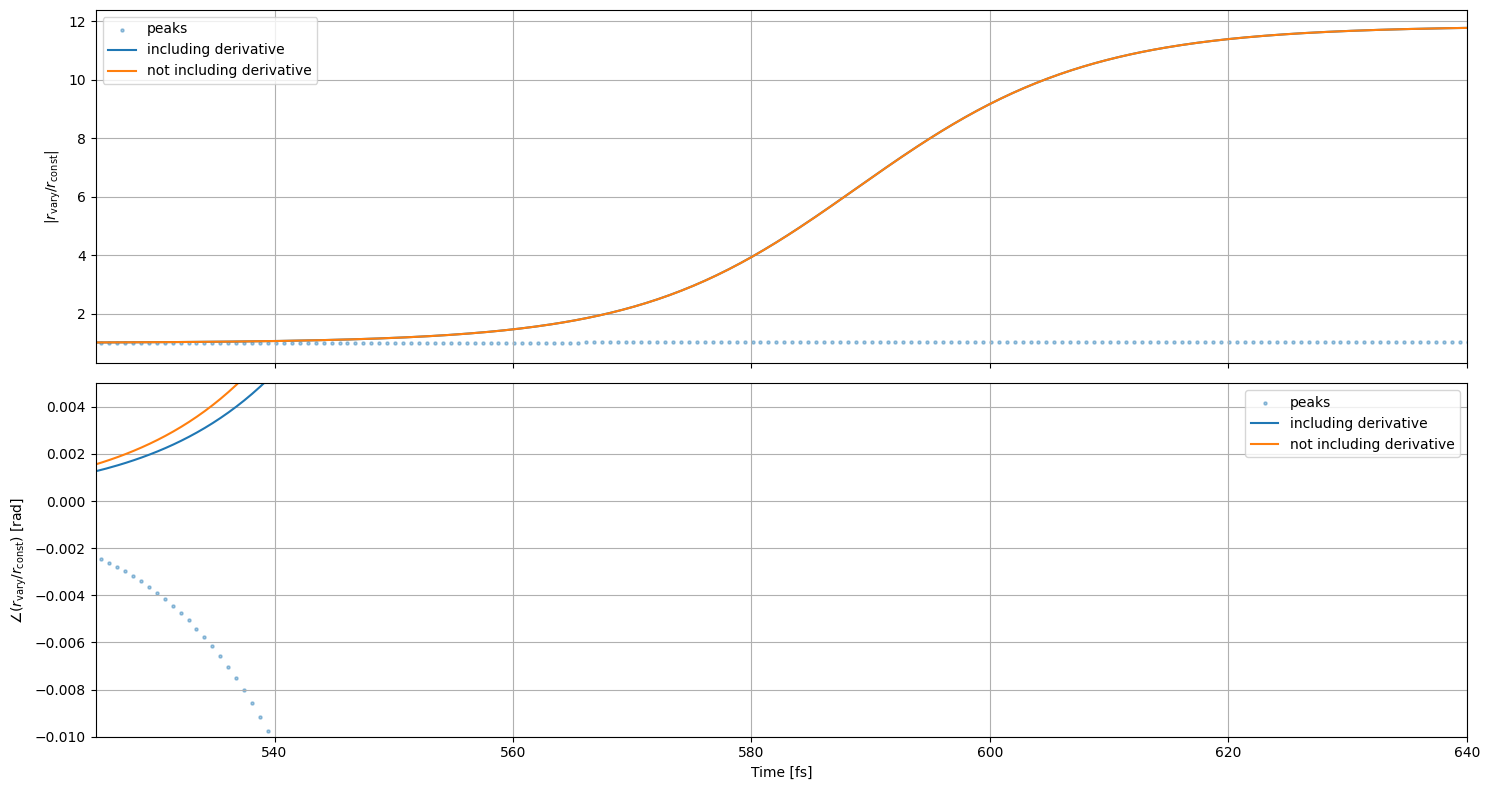

In [ ]:
delta_t_correction = (
    result_withfilm_vary["params"].metal_i0
    - result_withfilm_vary["params"].probe_r_i
) * dz_retrieved / C0_SI

t_peaks_fs = t_mid * 1e15
t_theory_fs = (t_ax_reduced * UNIT_T + delta_t_correction) * 1e15

fig, ax = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]}
)

# -------------------------------
# Plot 1: Magnitude
# -------------------------------
ax[0].scatter(
    t_peaks_fs,
    np.abs(ratio_complex),
    s=5,
    alpha=0.4,
    label="peaks"
)

ax[0].plot(
    t_theory_fs,
    np.abs(r_ratio),
    label="including derivative"
)

ax[0].plot(
    t_theory_fs,
    np.abs(r_ratio_uncorrected),
    label="not including derivative"
)

ax[0].set_ylabel(r"$|r_{\mathrm{vary}}/r_{\mathrm{const}}|$")
ax[0].legend()
ax[0].grid(True)

# Optional magnitude limits
# ax[0].set_ylim((0.999, 1.03))


# -------------------------------
# Plot 2: Phase
# -------------------------------
ax[1].scatter(
    t_peaks_fs,
    np.angle(ratio_complex),
    s=5,
    alpha=0.4,
    label="peaks"
)

ax[1].plot(
    t_theory_fs,
    np.angle(r_ratio),
    label="including derivative"
)

ax[1].plot(
    t_theory_fs,
    np.angle(r_ratio_uncorrected),
    label="not including derivative"
)

ax[1].set_xlabel("Time [fs]")
ax[1].set_ylabel(r"$\angle(r_{\mathrm{vary}}/r_{\mathrm{const}})$ [rad]")
ax[1].legend()
ax[1].grid(True)

ax[1].set_xlim((5.25e2, 6.4e2))
ax[1].set_ylim((-0.01, 0.005))

plt.tight_layout()
plt.show()

### Check peaks analysis against theory, for a semi-infinite metal region

In [83]:
# perform a forward model check with the complex transfer function from the peak analysis

from lightmatter.infer_drude_reflection import epsilon_drude
from lightmatter.infer_drude_reflection import r_model_from_params

def ref_trans_coeffs(omega, n_complex,thickness):

    delta = (omega / C0_SI) * n_complex * thickness
    denom = (
        np.cos(delta)
        - 0.5j * (n_complex + 1.0 / n_complex) * np.sin(delta)
    )
    t_c = 1.0 / denom

    r_c = (
        0.5j * (n_complex - 1.0 / n_complex) * np.sin(delta)
    ) / denom

    return r_c,t_c

num_reflections = 100
Nt_reduced = Nt//100
r_ratio = np.zeros(Nt_reduced, dtype=np.complex128)
t_ax_reduced = np.linspace(0.0,T,Nt_reduced)
delta_t_grad = (t_ax_reduced[1] - t_ax_reduced[0]) * UNIT_T
print(f"T:{T}, 1/dt_reduced:{np.round(1/(t_ax_reduced[1] - t_ax_reduced[0])*1/UNIT_T,3)}")

omega_D_timedep_reduced = omega_D_smoothstep(t_ax_reduced, omega_D0, 3000, 0.45, 0.02)
omega_arr = np.array([2*np.pi*f0_retr,]) * UNIT_F               # Ensuring this is the same as the retrieved pulse
eps_drude = np.zeros(Nt_reduced,dtype=np.complex128)
r_dyn_old = np.zeros(Nt_reduced,dtype=np.complex128)

r_dyn_modified = np.zeros(Nt_reduced, dtype=np.complex128)

for i in range(Nt_reduced):

    eps_drude[i] = epsilon_drude(
        omega=omega_arr,
        eps_inf=5.9673,
        omega_D=omega_D_timedep_reduced[i]*UNIT_F,
        gamma_D=gamma_D0*UNIT_F
    )[0]

    # r_dyn_old[i] = r_model_from_params(
    #     omega=omega_arr,
    #     omega_D=omega_D_timedep_reduced[i]*UNIT_F,
    #     gamma_D=gamma_D0*UNIT_F,
    #     eps_inf=5.9673,
    #     d_m=thickness_retrieved,
    #     N_reflections=num_reflections,
    # )
# time-constant case
eps_drude_const = epsilon_drude(omega_arr, eps_inf=5.9673, omega_D=omega_D0*UNIT_F, gamma_D=gamma_D0*UNIT_F, )
n_complex_const = np.sqrt(eps_drude_const)


# Check the expected reflection coefficient for a time-varying refractive index.

del_eps_del_t = np.gradient(eps_drude,delta_t_grad)
n_sqr = eps_drude + 1.0j/omega_arr[0] * del_eps_del_t
n_complex = np.sqrt(n_sqr)

# modified eqn
l_eff = C0_SI/omega_arr[0] * np.sqrt(2.0/(np.abs(eps_drude_const) - np.real(eps_drude_const)))
n_sqr_modified = 1.0 - 1.0j*omega_arr[0] * l_eff / C0_SI * (eps_drude - 1.0 + 1.0j/omega_arr[0] * del_eps_del_t)
n_complex_modified = np.sqrt(n_sqr_modified)

n_sqr_uncorrected = eps_drude
n_complex_uncorrected = np.sqrt(eps_drude)

# thick case
r_complex_vary_thick,t_complex_vary_thick = ref_trans_coeffs(omega_arr[0], n_complex, thickness_retrieved)

# single interface Fresnel equation
r_complex_vary_thick_modified = (1.0 - n_complex_modified) / (1.0 + n_complex_modified)
r_complex_const_singleinterface = (1.0 - n_complex_const) / (1.0 + n_complex_const)

r_complex_constant_thick, t_complex_constant_thick = ref_trans_coeffs(omega_arr[0],n_complex_const, thickness_retrieved)

r_ratio_modified = r_complex_vary_thick_modified / r_complex_const_singleinterface
r_ratio = r_complex_vary_thick/r_complex_constant_thick
t_ratio = t_complex_vary_thick/t_complex_constant_thick

# define the uncorrected reflection coefficient
r_complex_uncorrected, t_complex_uncorrected = ref_trans_coeffs(omega_arr[0], n_complex_uncorrected, thickness_retrieved)
r_ratio_uncorrected = r_complex_uncorrected / r_complex_constant_thick

T:0.889, 1/dt_reduced:3026996625421822.0


In [84]:
r_ratio

array([1.        -0.j       , 1.        -0.j       ,
       1.        -0.j       , ..., 0.91960952-0.4543584j,
       0.91960952-0.4543584j, 0.91960952-0.4543584j], shape=(2692,))

In [85]:
from lightmatter.infer_drude_comp_const_interpolate import extract_peak_ratio_time_series_from_reflections

t_mid, ratio_complex, aux = extract_peak_ratio_time_series_from_reflections(
    E_r_const,
    E_r_vary,
    t_ax_retrieved,
    f0,
    peak_prom_frac=0.05,
    peak_tol_frac=0.45,
    clip=2,
)

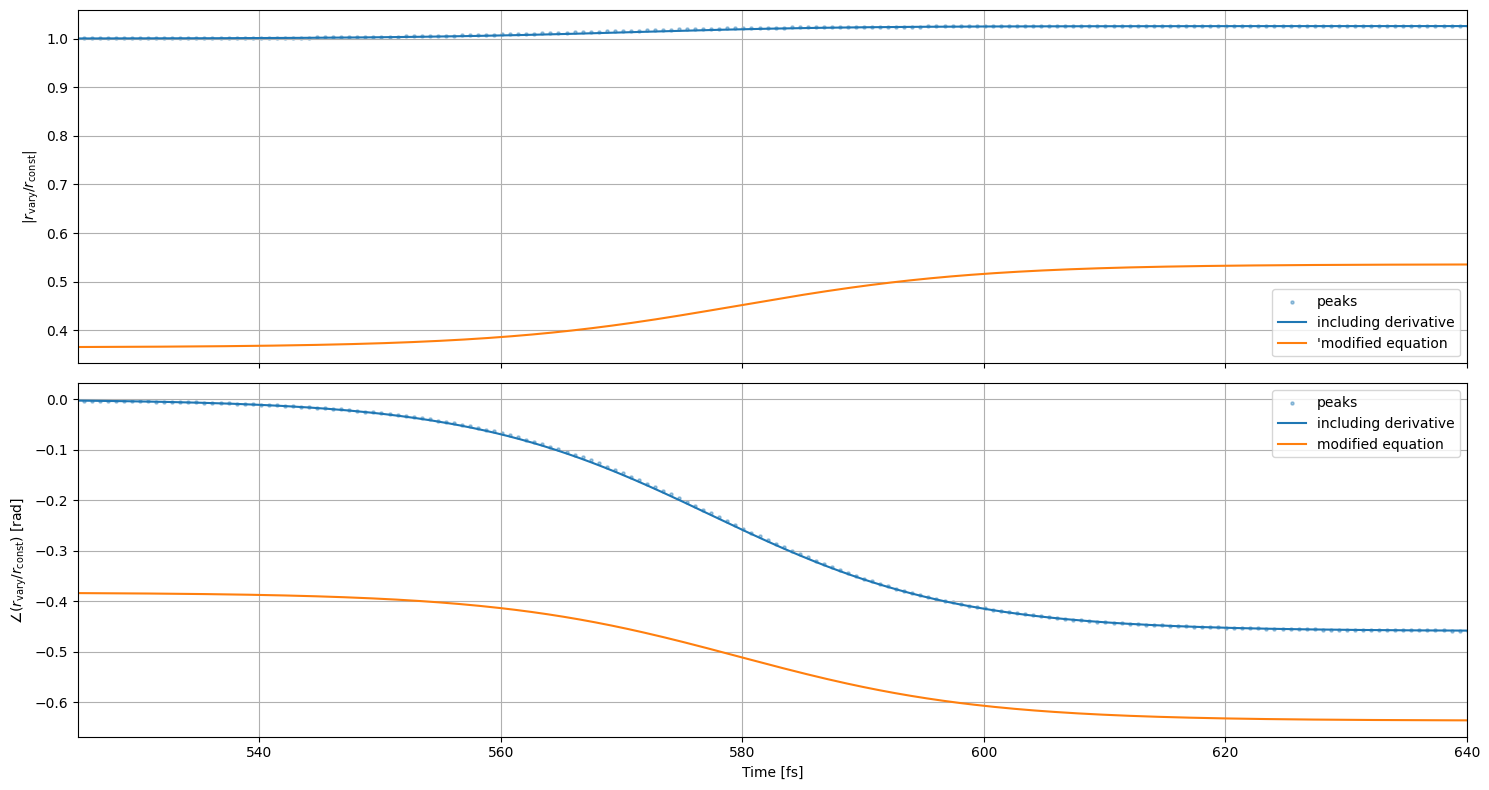

In [87]:
delta_t_correction = (
    result_withfilm_vary["params"].metal_i0
    - result_withfilm_vary["params"].probe_r_i
) * dz_retrieved / C0_SI

t_peaks_fs = t_mid * 1e15
t_theory_fs = (t_ax_reduced * UNIT_T + delta_t_correction) * 1e15

fig, ax = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]}
)

# -------------------------------
# Plot 1: Magnitude
# -------------------------------
ax[0].scatter(
    t_peaks_fs,
    np.abs(ratio_complex),
    s=5,
    alpha=0.4,
    label="peaks"
)

ax[0].plot(
    t_theory_fs,
    np.abs(r_ratio),
    label="including derivative"
)

ax[0].plot(
    t_theory_fs,
    np.abs(r_ratio_modified),
    label="'modified equation"
)

ax[0].set_ylabel(r"$|r_{\mathrm{vary}}/r_{\mathrm{const}}|$")
ax[0].legend()
ax[0].grid(True)

# Optional magnitude limits
# ax[0].set_ylim((0.995, 1.04))


# -------------------------------
# Plot 2: Phase
# -------------------------------
ax[1].scatter(
    t_peaks_fs,
    np.angle(ratio_complex),
    s=5,
    alpha=0.4,
    label="peaks"
)

ax[1].plot(
    t_theory_fs,
    np.angle(r_ratio),
    label="including derivative"
)

ax[1].plot(
    t_theory_fs,
    np.angle(r_ratio_modified),
    label="modified equation"
)

ax[1].set_xlabel("Time [fs]")
ax[1].set_ylabel(r"$\angle(r_{\mathrm{vary}}/r_{\mathrm{const}})$ [rad]")
ax[1].legend()
ax[1].grid(True)

ax[1].set_xlim((5.25e2, 6.4e2))
# ax[1].set_ylim((-0.01, 0.005))

plt.tight_layout()
plt.show()

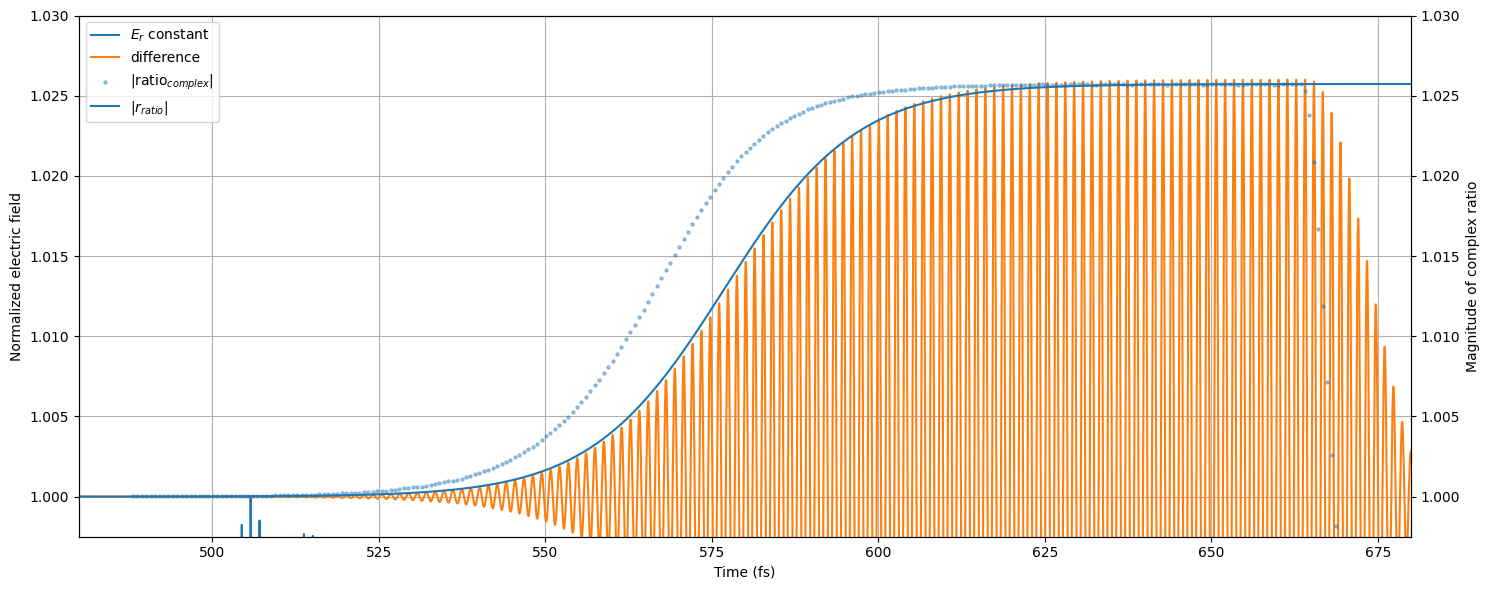

In [21]:
# -----------------------
# Time correction for ratio trace
# -----------------------
delta_t_correction = (
    result_withfilm_vary["params"].metal_i0
    - result_withfilm_vary["params"].probe_r_i
) * dz_retrieved / C0_SI

# -----------------------
# Figure and left axis
# -----------------------
fig, ax1 = plt.subplots(figsize=(15, 6))

# Normalize fields using the same reference
E_norm_ref = np.max(np.abs(E_r_const))

ax1.plot(
    t_ax_retrieved * 1e15,
    E_r_const / E_norm_ref,
    label=r"$E_r$ constant",
)

ax1.plot(
    t_ax_retrieved * 1e15,
    1 + 0.026*(E_r_vary - E_r_const) / np.max(E_r_vary - E_r_const),
    label="difference"
)

# ax1.plot(
#     t_ax_retrieved * 1e15,
#     E_r_vary / E_norm_ref,
#     alpha=0.5,
#     label=r"$E_r$ varying",
# )

ax1.set_xlabel("Time (fs)")
ax1.set_ylabel("Normalized electric field")
# ax1.set_xlim(5.75e2, 5.85e2)
ax1.set_xlim((4.8e2,6.8e2))
ax1.set_ylim(0.9975, 1.03)
ax1.grid(True)

# -----------------------
# Right axis for ratio
# -----------------------
ax2 = ax1.twinx()

ax2.scatter(
    t_mid * 1e15,
    np.abs(ratio_complex),
    s=5,
    alpha=0.4,
    label=r"$|\mathrm{ratio}_{complex}|$",
)

ax2.plot(
    (t_ax_reduced * UNIT_T + delta_t_correction) * 1e15 + 3,
    np.abs(r_ratio),
    label=r"$|r_{ratio}|$",
)

ax2.set_ylabel("Magnitude of complex ratio")

# Set independently because this axis may have different scaling
ax2.set_ylim(0.9975, 1.03)
# ax2.set_ylim(0.0, 1.03)

# -----------------------
# Combined legend
# -----------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best",
)

plt.tight_layout()
plt.show()

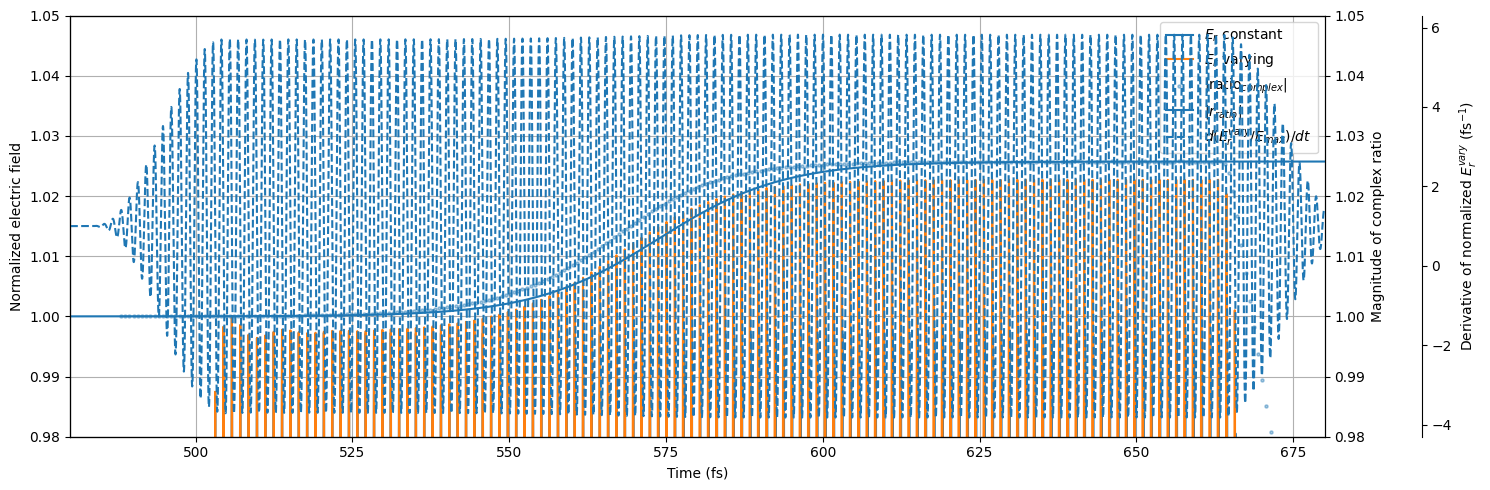

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Time correction for ratio trace
# -----------------------
delta_t_correction = (
    result_withfilm_vary["params"].metal_i0
    - result_withfilm_vary["params"].probe_r_i
) * dz_retrieved / C0_SI

# -----------------------
# Normalize electric fields
# -----------------------
E_norm_ref = np.max(np.abs(E_r_const))

E_const_norm = E_r_const / E_norm_ref
E_vary_norm  = E_r_vary  / E_norm_ref

# Time axis in fs
t_retrieved_fs = t_ax_retrieved * 1e15

# -----------------------
# Derivative of varying electric field trace
# Units: normalized field per fs
# -----------------------
dE_vary_dt = np.gradient(E_vary_norm, t_retrieved_fs)

# -----------------------
# Figure and left axis: electric fields
# -----------------------
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(
    t_retrieved_fs,
    E_const_norm,
    label=r"$E_r$ constant",
)

ax1.set_xlabel("Time (fs)")
ax1.set_ylabel("Normalized electric field")
ax1.set_xlim(4.8e2, 6.8e2)
ax1.set_ylim(0.98, 1.05)
ax1.grid(True)

# -----------------------
# Right axis 1: ratio_complex and r_ratio
# -----------------------
ax2 = ax1.twinx()

ax2.scatter(
    t_mid * 1e15,
    np.abs(ratio_complex),
    s=5,
    alpha=0.4,
    label=r"$|\mathrm{ratio}_{complex}|$",
)

ax2.plot(
    (t_ax_reduced * UNIT_T + delta_t_correction) * 1e15,
    np.abs(r_ratio),
    label=r"$|r_{ratio}|$",
)

ax2.set_ylabel("Magnitude of complex ratio")
ax2.set_ylim(0.98, 1.05)
# ax2.set_ylim(0.0, 1.03)

# -----------------------
# Right axis 2: derivative of varying electric field
# -----------------------
ax3 = ax1.twinx()

# Offset the third axis outward so it does not overlap with ax2
ax3.spines["right"].set_position(("outward", 70))

ax3.plot(
    t_retrieved_fs,
    dE_vary_dt + 1.0,
    linestyle="--",
    label=r"$d(E_r^{vary}/E_{max})/dt$",
)

ax3.set_ylabel(r"Derivative of normalized $E_r^{vary}$ $(\mathrm{fs}^{-1})$")

# Optional: set derivative axis limits manually if needed
# ax3.set_ylim(-1e-3, 1e-3)

# -----------------------
# Combined legend
# -----------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2 + lines3,
    labels1 + labels2 + labels3,
    loc="best",
)

plt.tight_layout()
plt.show()

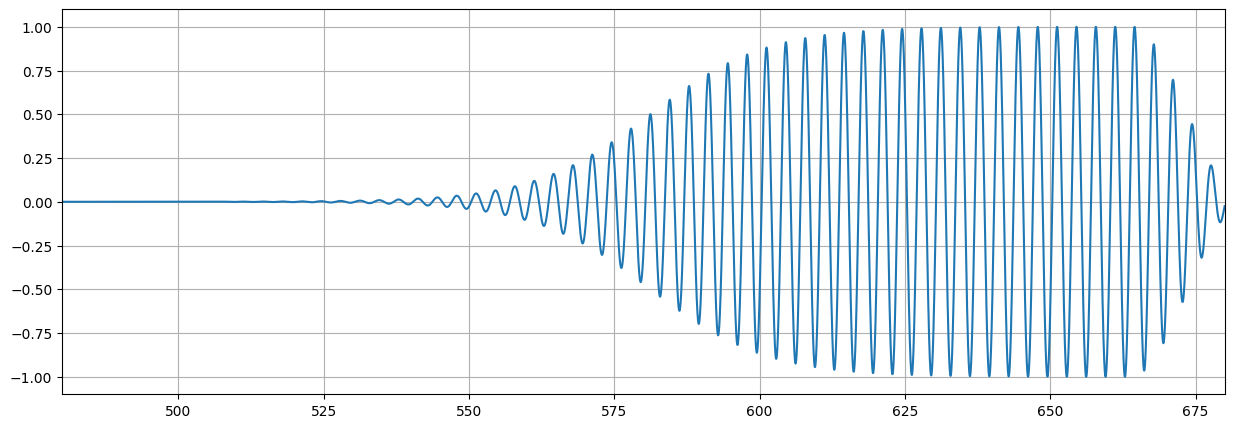

In [20]:
fig = plt.figure(figsize=(15,5))

plt.plot(t_ax_retrieved * 1e15, (E_r_vary - E_r_const) / (np.max(E_r_vary - E_r_const)))
plt.xlim((4.8e2,6.8e2))
# plt.ylim((0.,1.03))
# plt.ylim((0.999, 1.003))
plt.grid(True)


(5e-13, 7e-13)

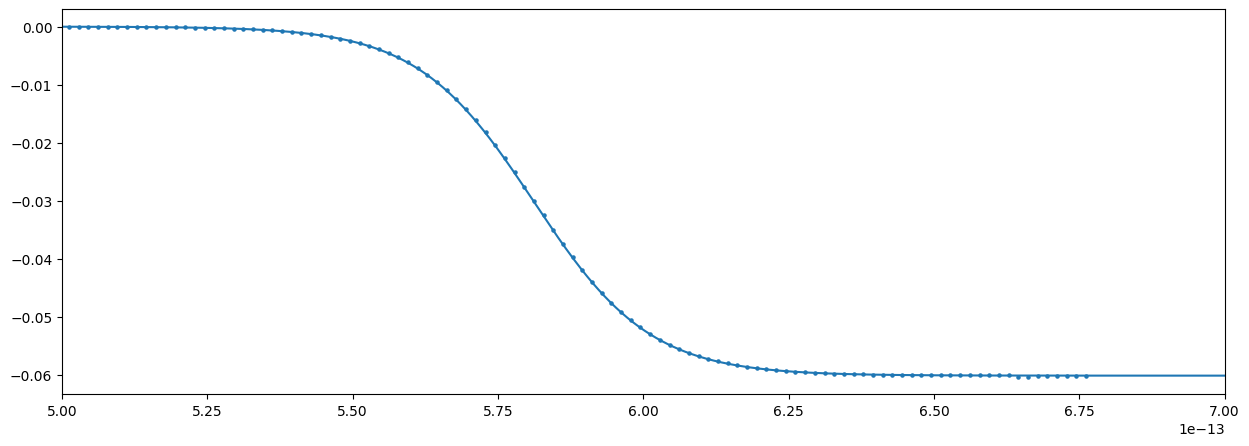

In [12]:
fig = plt.figure(figsize=(15,5))

plt.scatter(t_mid, np.angle(ratio_complex),s=5)
plt.plot(t_ax_reduced*UNIT_T + delta_t_correction, np.angle(r_ratio))
plt.xlim((5e-13,7e-13))
# plt.ylim((-0.005,0.002))

In [ ]:
from lightmatter.infer_drude_comp_const import infer_drude_time_series_from_multifrequency_runs

dirname_compare_const = ["2026-05-31_reflection_compare_thin5_lowres","step_dz_5"]
result_inference_compare_const = infer_drude_time_series_from_multifrequency_runs(
    f0_arr=[650.0,750.0,850.0],
    dirname=dirname_compare_const,
    interpolation=True,
    eps_inf=5.9673,
    omega_D0=omega_D0*UNIT_F,
    gamma_D0=gamma_D0*UNIT_F,
    N_reflections=100,
    x0=(1.32e16,1.0e14),
    bounds=((5e15, 5e13), (2.e16, 1.5e14)),
    lam_smooth=0.0,
    clip = 10
)

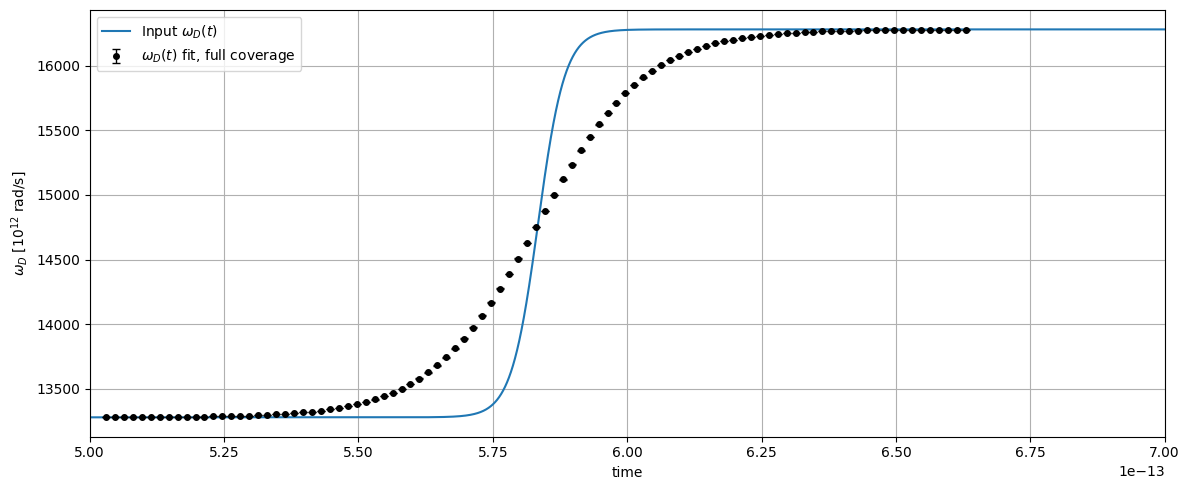

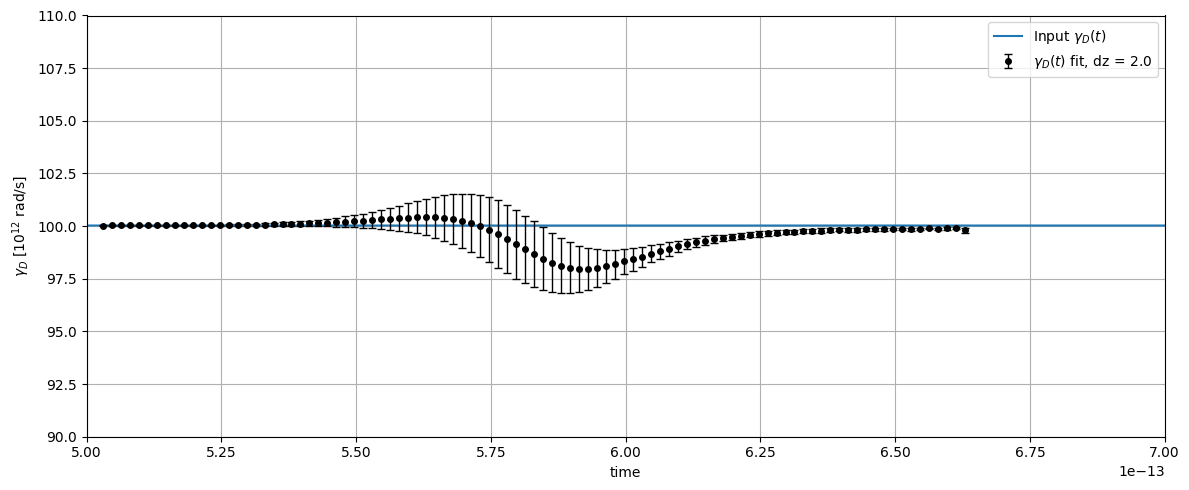

In [46]:
delta_t_correction = (result_withfilm_vary["params"].metal_i0 - result_withfilm_vary["params"].probe_r_i)*dz_retrieved / C0_SI


t_fit_full = result_inference_compare_const["time"]
omegaD_t_full = result_inference_compare_const["omegaD_t"]
gammaD_t_full = result_inference_compare_const["gammaD_t"]
omegaD_err_full = result_inference_compare_const["omegaD_err"]
gammaD_err_full = result_inference_compare_const["gammaD_err"]


# time_correction = -2.0*(probe_r_i - metal_i0) * dz * UNIT_L / C0_SI

# Optional scaling for nicer axes
omega_scale = 1e-12   # plot omega_D in units of 1e12 rad/s
gamma_scale = 1e-12   # plot gamma_D in units of 1e12 rad/s

plt.figure(figsize=(12, 5))
plt.plot(t_ax * UNIT_T + delta_t_correction, omega_D_timedep, label="Input $\omega_D(t)$")
# plt.scatter(t_fit_full,omegaD_t_full*omega_scale,s=5,alpha=0.7)
plt.errorbar(
    t_fit_full,
    omegaD_t_full * omega_scale,
    yerr=omegaD_err_full * omega_scale,
    fmt='o',
    color='black',
    alpha=1,
    capsize=3,
    elinewidth=1,
    markersize=4,
    label=r'$\omega_D(t)$ fit, full coverage'
)

plt.xlabel("time")
plt.ylabel(r'$\omega_D$ [$10^{12}$ rad/s]')
plt.xlim((5e-13,7e-13))
# plt.xlim((3.5e-13,5.5e-13))
# plt.ylim((13000,17500))
# plt.ylim((0.,6e4))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(12, 5))
plt.plot(t_ax * UNIT_T + delta_t_correction, gamma_D_const, label="Input $\gamma_D(t)$")
plt.errorbar(
    t_fit_full,
    gammaD_t_full * gamma_scale,
    yerr=gammaD_err_full * gamma_scale,
    fmt='o',
    color='black',
    capsize=3,
    elinewidth=1,
    markersize=4,
    label=r'$\gamma_D(t)$ fit, dz = 2.0'
)

plt.xlabel("time")
plt.ylabel(r'$\gamma_D$ [$10^{12}$ rad/s]')
plt.ylim((90.,110.))
plt.xlim((5e-13,7e-13))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [16]:
gammaD_t_full.shape

(58817,)

peaks in incident 59
peaks in output 58
peaks in incident 69
peaks in output 68
peaks in incident 79
peaks in output 78
peaks in incident 97
peaks in output 98
peaks in incident 117
peaks in output 117
peaks in incident 127
peaks in output 127


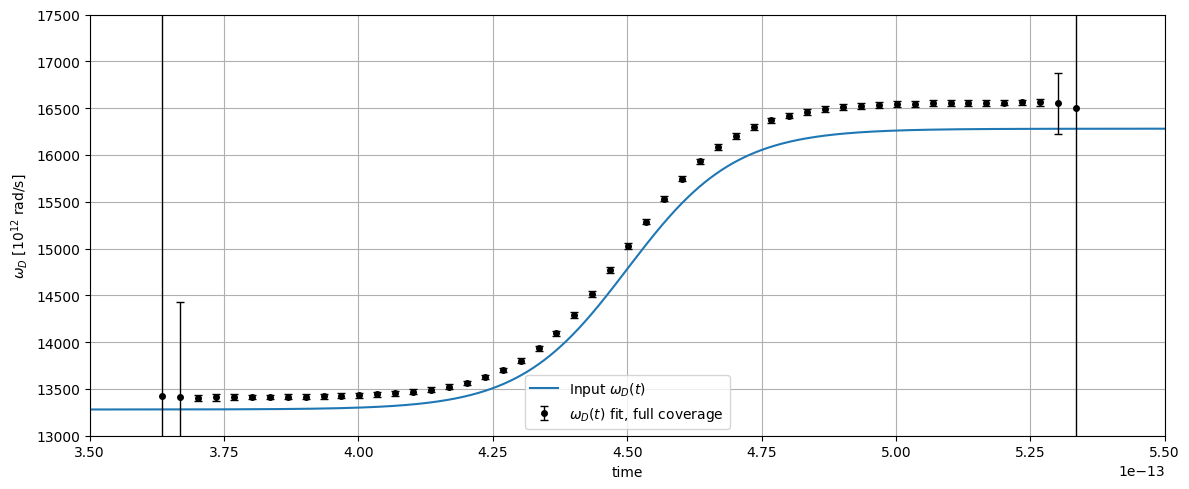

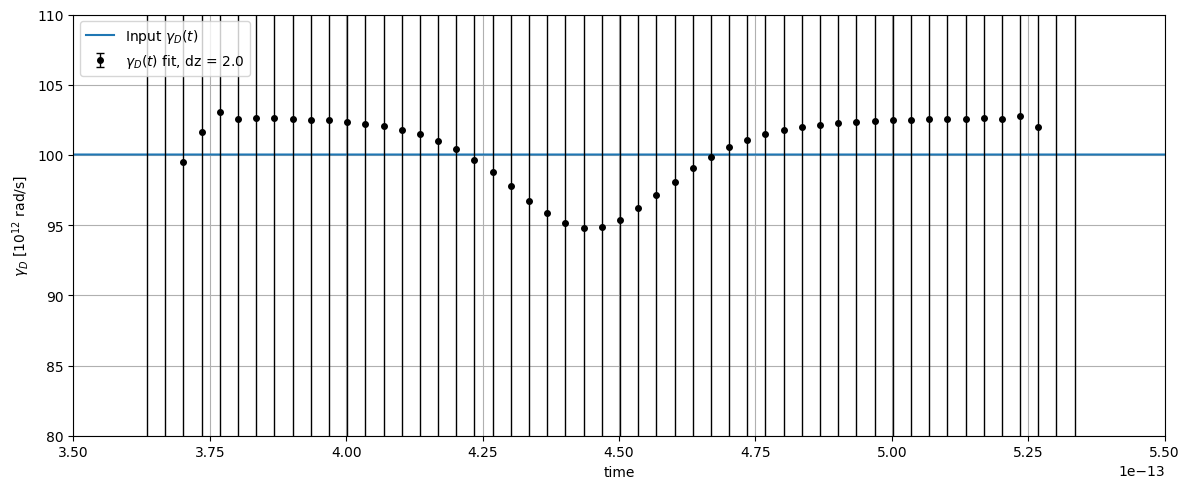

In [ ]:
from lightmatter.infer_drude_reflection import infer_drude_time_series_from_multifrequency_runs

dirname_infer = ["2026-04-22_corrected_pml_reflection_fit","step_dz_10"]
result_inference_reflections = infer_drude_time_series_from_multifrequency_runs(
    f0_arr=[300.0,350.0,400.0,500.0,600.0,650.0],
    dirname=dirname_infer,
    eps_inf=5.9673,
    N_reflections=0,
    env_frac=0.2,
    x0=(1.32e16, 1.0e14),
    bounds=((5e15, 5e13), (5e16, 1.5e14)),
    lam_smooth=0.0,   # tune this
)


t_fit_full = result_inference_reflections["time"]
omegaD_t_full = result_inference_reflections["omegaD_t"]
gammaD_t_full = result_inference_reflections["gammaD_t"]
omegaD_err_full = result_inference_reflections["omegaD_err"]
gammaD_err_full = result_inference_reflections["gammaD_err"]


# time_correction = -2.0*(probe_r_i - metal_i0) * dz * UNIT_L / C0_SI

# Optional scaling for nicer axes
omega_scale = 1e-12   # plot omega_D in units of 1e12 rad/s
gamma_scale = 1e-12   # plot gamma_D in units of 1e12 rad/s

plt.figure(figsize=(12, 5))
plt.plot(t_ax * UNIT_T, omega_D_timedep, label="Input $\omega_D(t)$")
plt.errorbar(
    t_fit_full,
    omegaD_t_full * omega_scale,
    yerr=omegaD_err_full * omega_scale,
    fmt='o',
    color='black',
    capsize=3,
    elinewidth=1,
    markersize=4,
    label=r'$\omega_D(t)$ fit, full coverage'
)

plt.xlabel("time")
plt.ylabel(r'$\omega_D$ [$10^{12}$ rad/s]')
# plt.xlim((4.9e-13,6.4e-13))
plt.xlim((3.5e-13,5.5e-13))
plt.ylim((13000,17500))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.figure(figsize=(12, 5))
plt.plot(t_ax * UNIT_T, gamma_D_const, label="Input $\gamma_D(t)$")
plt.errorbar(
    t_fit_full,
    gammaD_t_full * gamma_scale,
    yerr=gammaD_err_full * gamma_scale,
    fmt='o',
    color='black',
    capsize=3,
    elinewidth=1,
    markersize=4,
    label=r'$\gamma_D(t)$ fit, dz = 2.0'
)

plt.xlabel("time")
plt.ylabel(r'$\gamma_D$ [$10^{12}$ rad/s]')
plt.ylim((80.,110.))
plt.xlim((3.5e-13,5.5e-13))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [4]:
#theory
from lightmatter.infer_drude_reflection import  r_finite_reflections, epsilon_drude

w = 700.0 * UNIT_F * 2.0*np.pi
r_timedep = np.zeros(Nt,dtype=np.complex128)

for i in range(Nt):
    epsilon = epsilon_drude(w, eps_inf=material.eps_inf[i], omega_D=material.omega_D[i]*UNIT_F, gamma_D=material.gamma_D[i]*UNIT_F)
    
    n_complex = np.sqrt(epsilon)

    r_timedep[i] = r_finite_reflections(
        n = np.real(n_complex),
        k = np.imag(n_complex),
        d_m = thickness_retrieved,
        w = w,
        N_reflections = 0,
    )

NameError: name 'thickness_retrieved' is not defined

(3.5e-13, 5.5e-13)

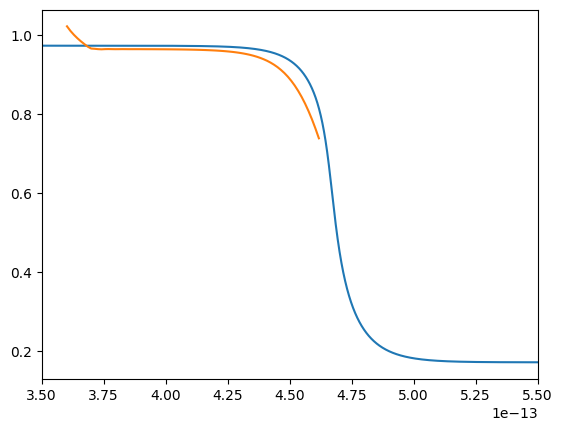

In [7]:
from lightmatter.infer_drude_reflection import build_multifrequency_reflection_dataset

dataset = build_multifrequency_reflection_dataset(
    f0_arr=[500.0,600.0,650.0,700.0],
    dirname= ["reflection_only","step_dz_10"],
)
# result_inference_reflections.keys()
# dataset["r_meas"][:,0].shape

# plt.plot(dataset["time"], np.real(dataset["r_meas"][:,2]))
# plt.plot(dataset["time"], np.imag(dataset["r_meas"][:,2]))

plt.plot(t_ax_retrieved,np.abs(r_timedep))
plt.plot(dataset["time"],np.abs(dataset["r_meas"][:,3]))
plt.xlim((3.5e-13,5.5e-13))

(3.5e-13, 5.5e-13)

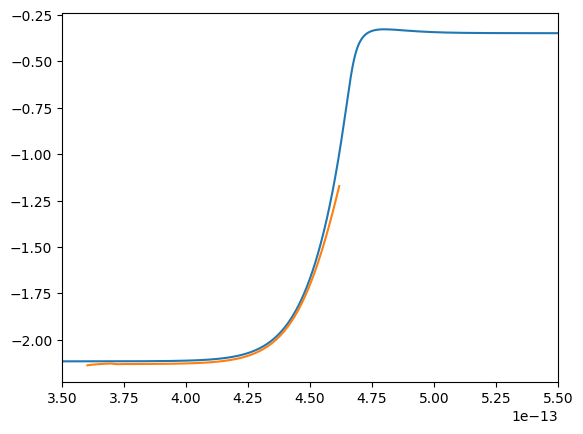

In [8]:
plt.plot(t_ax_retrieved,np.angle(r_timedep))
plt.plot(dataset["time"],np.angle(dataset["r_meas"][:,3]))
plt.xlim((3.5e-13,5.5e-13))

## Matched peaks


In [3]:
from lightmatter.peak_analyzer_modified_shift import match_peaks_and_transfer

def plot_peak_vs_shifted_diagnostics(
    E_trans,
    E_inc,
    t,
    f0,
    dt,
    thickness,
    env_frac=0.05,
    peak_prom_frac=0.05,
    time_unit=1e-12,
    time_label="Time (ps)",
    xlim=None,
):
    """
    Visualize the difference between:
    - peak-to-peak ratio
    - zero-shifted transmitted sampling ratio

    Parameters
    ----------
    E_trans, E_inc : arrays
        Transmitted and incident waveforms.
    t : array
        Time axis [s].
    f0 : float
        Carrier frequency [Hz].
    dt : float
        Time step [s].
    thickness : float
        Film thickness [m].
    env_frac, peak_prom_frac : float
        Parameters passed to match_peaks_and_transfer.
    time_unit : float
        Scale factor for time axis. Use 1e-12 for ps.
    time_label : str
        Label for time axis.
    xlim : tuple or None
        Optional x-axis limits in plotted units.
    """
    ratio_shifted, ratio, phase, dt_corr, matched, matched_zero = match_peaks_and_transfer(
        E_trans,
        E_inc,
        t,
        f0,
        dt,
        thickness,
        env_frac=env_frac,
        peak_prom_frac=peak_prom_frac,
        geom_phase_correction=0.0,
    )

    print(f"Number of matched zeros: {len(matched_zero)}")
    print(f"Number of matched peaks {len(matched)}")

    fig, ax = plt.subplots(figsize=(13, 6))

    ax.plot(t / time_unit, E_inc, label="Incident", linewidth=1.8)
    ax.plot(t / time_unit - dt_corr / time_unit, E_trans, label="Transmitted", linewidth=1.8)

    if len(matched_zero) == 0:
        ax.set_title("No matched peaks found")
        ax.set_xlabel(time_label)
        ax.set_ylabel("Electric field")
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        return fig, ax

    # Original matched peaks
    inc_ids = np.array([a for a, b in matched], dtype=int)
    tr_ids  = np.array([b for a, b in matched], dtype=int)

    ax.scatter(
        t[inc_ids] / time_unit,
        E_inc[inc_ids],
        s=45,
        marker="o",
        label="Incident peaks",
        zorder=5,
    )

    ax.scatter(
        (t[tr_ids] - dt_corr) / time_unit,
        E_trans[tr_ids],
        s=45,
        marker="s",
        label="Matched transmitted peaks",
        zorder=5,
    )

    # Zero-based shifted samples
    if len(matched_zero) > 0:
        inc_zero_ids = np.array([m[0] for m in matched_zero], dtype=int)
        tr_zero_ids  = np.array([m[1] for m in matched_zero], dtype=int)
        tz_inc = np.array([m[2] for m in matched_zero], dtype=float)
        tz_tr  = np.array([m[3] for m in matched_zero], dtype=float)

        t_peak_inc = t[inc_zero_ids]
        t_shift = tz_tr - tz_inc
        t_sample_tr = t_peak_inc + t_shift
        Etr_shifted = np.interp(t_sample_tr, t, E_trans)

        ax.scatter(
            (t_sample_tr-dt_corr) / time_unit,
            Etr_shifted,
            s=65,
            marker="x",
            linewidths=2.0,
            label="Transmitted sampled at zero-shifted time",
            zorder=6,
        )

        # connectors between incident peak time and shifted transmitted sampling time
        for ti, tsi, yi, ysi in zip(t_peak_inc, t_sample_tr, E_inc[inc_zero_ids], Etr_shifted):
            ax.plot(
                [ti / time_unit, (tsi - dt_corr) / time_unit],
                [yi, ysi],
                linestyle="--",
                linewidth=0.9,
                alpha=0.6,
            )

    ax.set_xlabel(time_label)
    ax.set_ylabel("Electric field")
    ax.set_title("Peak-based vs zero-shifted amplitude sampling")
    ax.grid(True)
    ax.legend()

    if xlim is not None:
        ax.set_xlim(xlim)

    plt.tight_layout()
    plt.show()
    return fig, ax

In [25]:
# retrieve
# retrieve stored data
dirname = "reflection_only/f0_700.0_step_dz_10"

result_withfilm = load_simulation_run(f"../output/{dirname}/with_film",nosnaps=False)
result_nofilm = load_simulation_run(f"../output/{dirname}/nofilm",nosnaps=False)

E_r_withfilm = result_withfilm["E_r"]
E_t_withfilm = result_withfilm["E_t"]
E_r_nofilm = result_nofilm["E_r"]
E_t_nofilm = result_nofilm["E_t"]

Nt = result_withfilm["params"].Nt
dt = result_withfilm["params"].dt * UNIT_T
dz_retrieved = result_withfilm["params"].dz * UNIT_L
t_ax_retrieved = np.arange(Nt) * dt
f0 = result_withfilm["pulse"].f0 * UNIT_F
thickness_retrieved = (result_withfilm['params'].metal_i1 - result_withfilm['params'].metal_i0) * result_withfilm['params'].dz * UNIT_L

simulation_params_withfilm = result_withfilm['params']

E_ref_only = E_r_withfilm - E_r_nofilm

plot_peak_vs_shifted_diagnostics(
    E_ref_only,
    E_r_nofilm,
    t_ax_retrieved,
    f0,
    dt,
    thickness,
    env_frac=0.05,
    peak_prom_frac=0.05,
    time_unit=1e-12,
    time_label="Time (ps)",
    xlim=(0.2,0.24), # rising edge
    # xlim=(0.39,0.44)
    # xlim=(0.3,0.352)
)

NameError: name 'plot_peak_vs_shifted_diagnostics' is not defined